In [11]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt 
import seaborn as sns


In [12]:
wine_df = pd.read_csv('winequality-red.csv')

In [13]:
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [14]:
wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

#the quality of wine 3 to 8 
#if 3 4 5 = low
#if 6 7 8 = high

In [15]:
wine_df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [16]:
print(wine_df["quality"].value_counts())


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


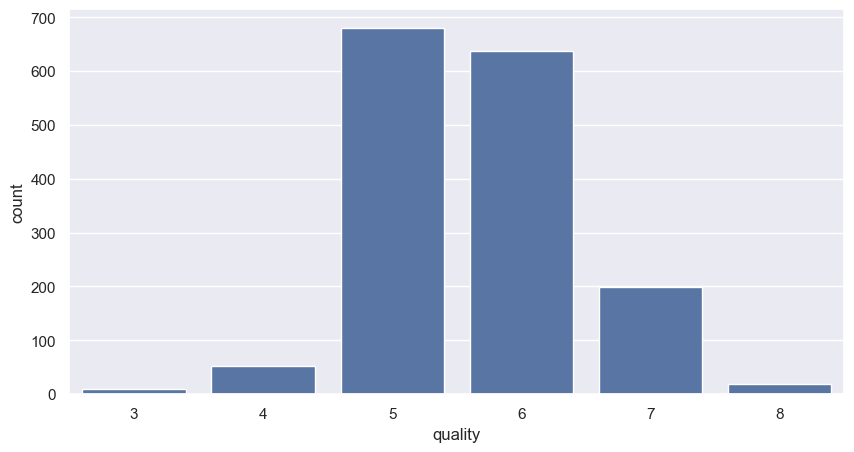

In [17]:
fig = plt.figure(figsize=(10, 5))
sns.countplot(x='quality',data=wine_df)
plt.show()

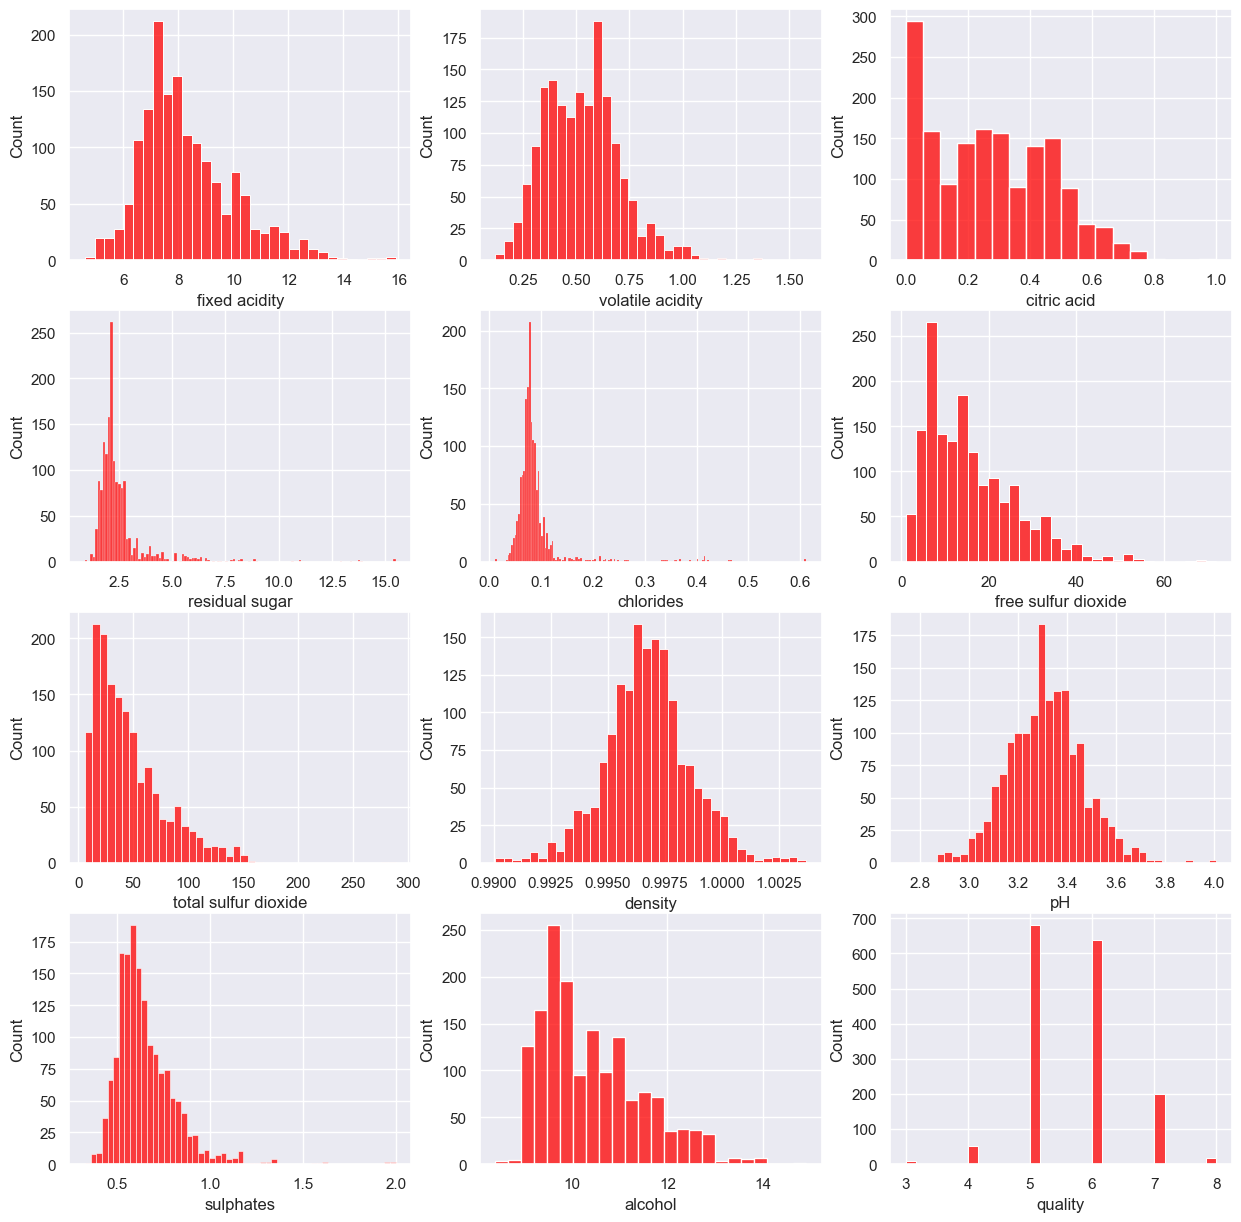

In [18]:
#Visulazation the distibtution of the all feature after log transformation
sns.set(style="darkgrid")
color = sns.color_palette("pastel")

fig , ax1 = plt.subplots(4,3, figsize=(15,15))
k = 0
coloumns = list(wine_df.columns)
for i in range (4):
    for j in range (3):
        if k < len(coloumns):
            sns.histplot(wine_df[coloumns[k]], ax=ax1[i][j] , color='red')
            k += 1

plt.show()

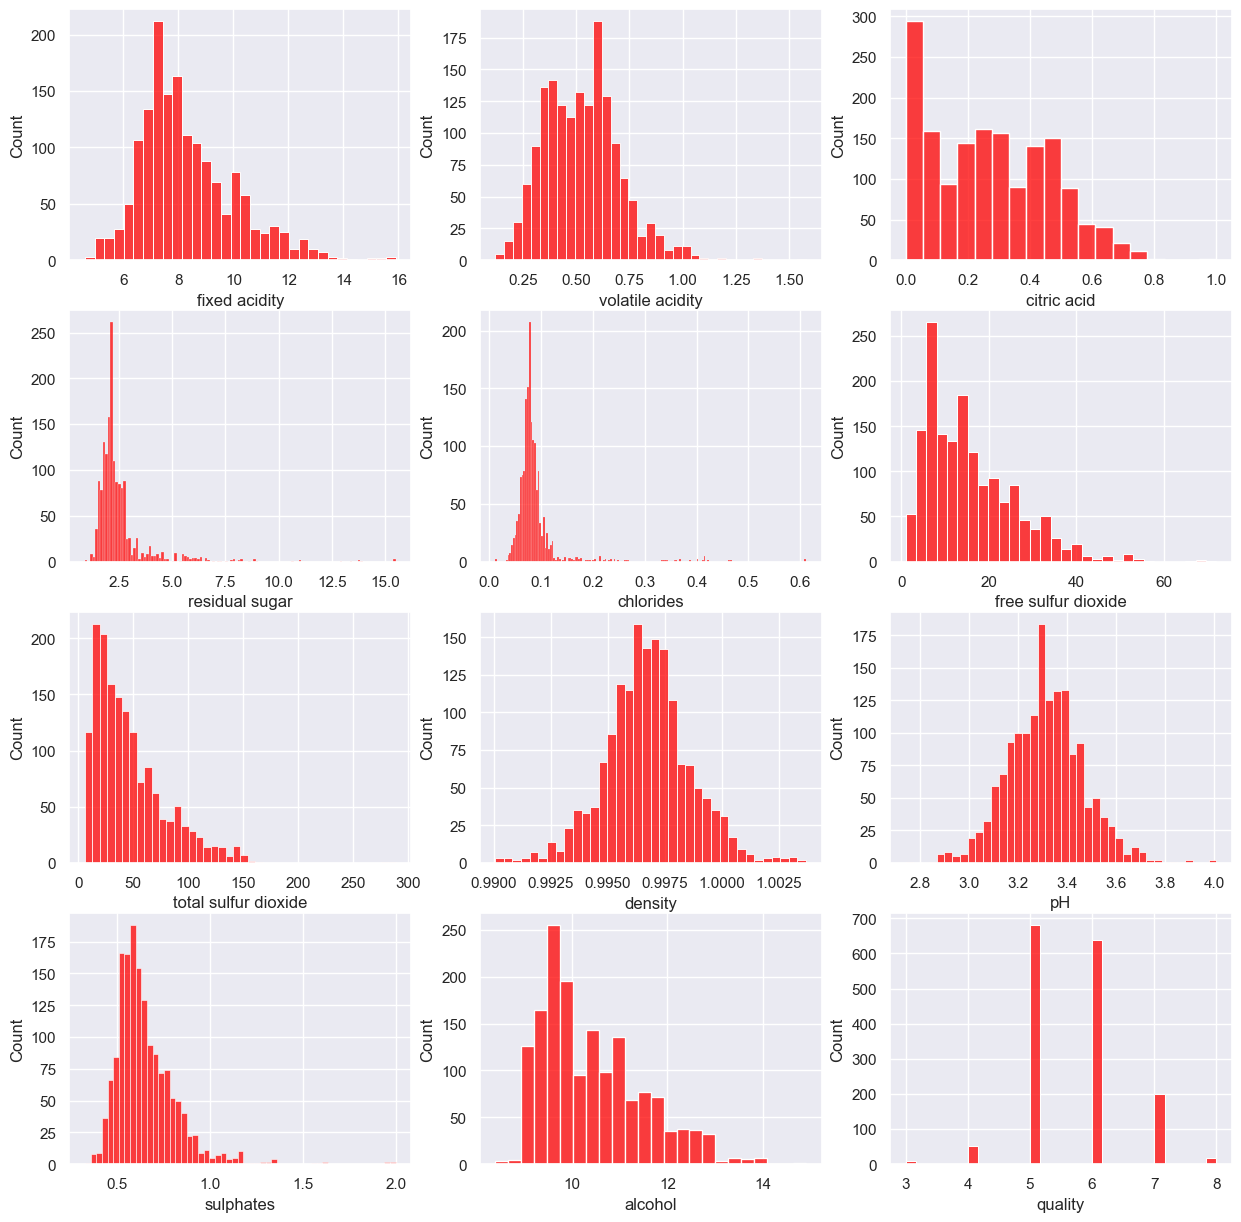

In [19]:
#Visulazation the distibtution of the all feature
sns.set(style="darkgrid")
color = sns.color_palette("pastel")

fig , ax1 = plt.subplots(4,3, figsize=(15,15))
k = 0
coloumns = list(wine_df.columns)
for i in range (4):
    for j in range (3):
        if k < len(coloumns):
            sns.histplot(wine_df[coloumns[k]], ax=ax1[i][j] , color='red')
            k += 1

plt.show()

In [22]:
wine_df.corr().sort_values(by='quality', ascending=False)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
quality,0.124052,-0.390558,0.226373,0.013732,-0.128907,-0.050656,-0.185100,-0.174919,-0.057731,0.251397,0.476166,1.000000
alcohol,-0.061668,-0.202288,0.109903,0.042075,-0.221141,-0.069408,-0.205654,-0.496180,0.205633,0.093595,1.000000,0.476166
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919


In [24]:
X = wine_df.drop('quality',axis = 1)
y = wine_df['quality']

In [25]:
#classify function
from sklearn.model_selection import train_test_split, cross_val_score

def classify(model,x,y):
    x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    model.fit(x_train,y_train)

    return model.score(x_test,y_test)*100

In [26]:
#logistic regression
from sklearn.linear_model import LogisticRegression

lm_rl = LogisticRegression()

accuracy_lr = classify(lm_rl, X, y)
print("LogisticRegression accuracy: {:<0.2f}".format(accuracy_lr))

LogisticRegression accuracy: 55.31


C:\Users\praha\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
#decision treee classifier
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
accuracy_dtc = classify(model, X, y)
print("DecisionTreeClassifier accuracy: {:<0.2f}". format(accuracy_dtc))

DecisionTreeClassifier accuracy: 57.81


In [28]:
#random forest classifier
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
accuracy_lr = classify(model, X, y)
print("RandomForestClassifier accuracy: {:<0.2f}". format(accuracy_lr))

RandomForestClassifier accuracy: 66.88


C:\Users\praha\AppData\Local\Temp\ipykernel_23772\660026909.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='pastel')


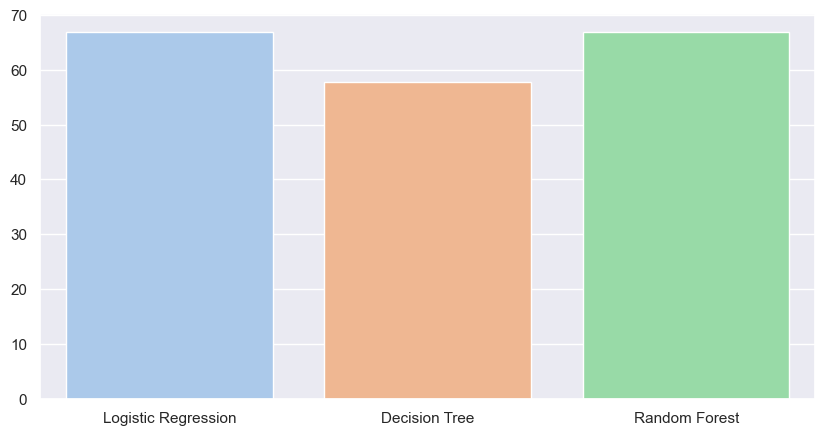

In [29]:
#ploting the accuracy of all models
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
accuracies = [accuracy_lr, accuracy_dtc, accuracy_lr]
plt.figure(figsize=(10,5))
sns.barplot(x=models, y=accuracies, palette='pastel') 
plt.show()  

In [32]:
#Predict the quality of wine 
#inserting new data
model = RandomForestClassifier()
model.fit(X, y)

sample_data = (7.9,0.35,0.46,3.6, 0.078, 15,37, 0.9973, 3.35, 0.86,12.8)
sample_data = numpy.array(sample_data).reshape(1,-1)
prediction = model.predict(sample_data)
print("Predicted wine quality:", prediction[0])

Predicted wine quality: 8


C:\Users\praha\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [89]:
import pickle
with open('wine_quality_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    print("Model saved to wine_quality_model.pkl successfully.")

Model saved to wine_quality_model.pkl successfully.


In [33]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("winequality-red.csv")

# Features (11 columns)
X = df.drop("quality", axis=1)

# Target
y = df["quality"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Save model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model trained with", model.n_features_in_, "features")

Model trained with 11 features


In [34]:
print(model.n_features_in_)


11
